# Módulos

In [49]:
import cv2
import re
import json
import pytesseract
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [50]:
config = r'--tessdata-dir tessdata'

# Implementação

## Lendo Imagem Bruta

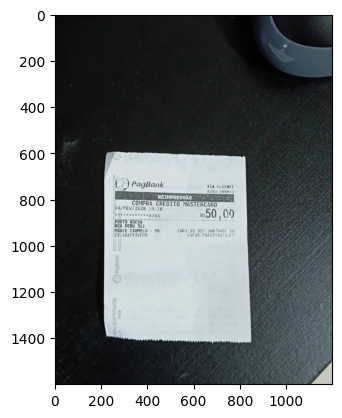

In [51]:
img = mpimg.imread('comp02.jpeg') # Carrega a imagem
plt.imshow(img) # Exibe a imagem

### Teste coleta imagem bruta

In [52]:
texto = pytesseract.image_to_string(img, lang='por',config=config)
print(texto)

)POQBOHÁ' VIA CLIENTE

POSTO ROCHA

RUA PERU 311
MONTE CARMELO - ME
CV: ADAPTIVEPO

é




## Convertendo escala para cinza

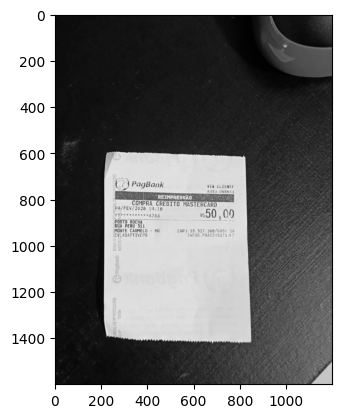

In [53]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')

### Teste coleta imagem com escala cinza

In [54]:
texto = pytesseract.image_to_string(gray, lang='por',config=config)
print(texto)

( TJ) PagBank VIA CLIENTE

EDITO MASTERCARD
POSTO ROCHA

=50,00
RUA PERU 311

MONTE CARMELO - MG CNPJ;55.32

PTIVEPO )




## Redimensionamento

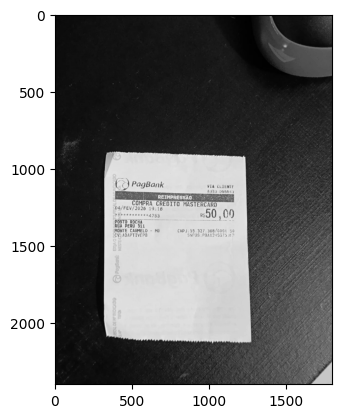

In [55]:
rel = cv2.resize(gray, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)
plt.imshow(rel, cmap='gray')

In [56]:
texto = pytesseract.image_to_string(rel, lang='por',config=config)
print(texto)

( 4 ) PagBank VIA CLIENTE

POSTO ROCHA

RUA PERU 311
CARMELOD -
PTIVEPO




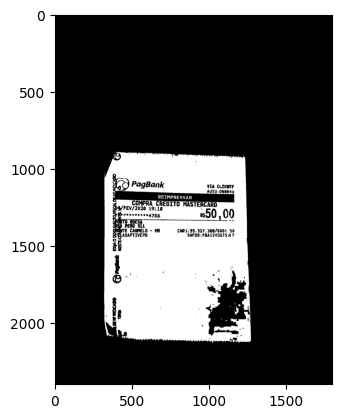

In [57]:
val, thresh_simples = cv2.threshold(rel, 210, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_simples, cmap='gray')

In [58]:
texto = pytesseract.image_to_string(thresh_simples, lang='por',config=config)
print(texto)

VIA CLIENTE
AUTU: 066643

FEV?%):HI:RXAQ .É%EDIÍD MASTERCARD
d.ao..v'c47ái ”50 0_0_

CNPJ:59.327.368/0001 30
SNPOS : PBA1245G75 R 9




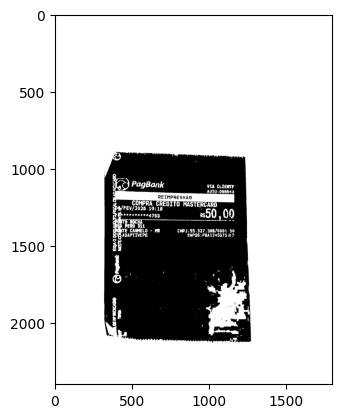

In [59]:
invert = 255 - thresh_simples
plt.imshow(invert, cmap='gray')

In [60]:
texto = pytesseract.image_to_string(invert, lang='por',config=config)
print(texto)

VIA CLIENTE
AUTU: 066643

FEV?%):HI:RXAQ .É%EDIÍD MASTERCARD
d.ao..v'c47ái ”50 0_0_

CNPJ:59.327.368/0001 30
SNPOS : PBA1245G75 R 9




In [121]:
import cv2
import numpy as np

# 1. Carregar a imagem
img2 = cv2.imread('comp02.jpeg')

# 2. Converter para cinza
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# 3. Redimensionar (aumentar para melhorar leitura se necessário)
resized = cv2.resize(gray2, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# 4. Remover ruído com desfoque gaussiano
denoised = cv2.GaussianBlur(resized, (5, 5), 0)

# 5. Binarização (Preto e Branco)
_, binary = cv2.threshold(denoised, 199, 255,cv2.THRESH_BINARY)

# Salvar o resultado
cv2.imwrite('imagem_processada.png', binary)
texto = pytesseract.image_to_string(binary, lang='por',config=config)
print(texto)

VIA CLIENTF
AUTU : 066643

REIMPRESSAÃO

COMPRA CREDITO MASTERCARD
FEV/2026 19:16

12424249 T47T53 ”50 00
õ ——

—— — —

CNPJ:58.327.368/000t 50
ADAPTIVEPO SNPOS : PBA1245G73 R ?




In [62]:
import cv2
import pytesseract
import re
import numpy as np
import json

# Configuração do caminho do Tesseract (ajuste se necessário)
# pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

def remover_fundo_e_marcas(image_path):
    # 1. Carregar a imagem
    img = cv2.imread(image_path)
    
    # 2. Converter para Tons de Cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 3. Criar uma máscara do fundo (dilatação remove o texto e mantém o fundo/marcas)
    # O kernel maior (7,7) ajuda a "apagar" o texto para identificar o que é fundo
    kernel = np.ones((7,7), np.uint8)
    background = cv2.dilate(gray, kernel, iterations=1)
    background = cv2.GaussianBlur(background, (21, 21), 0)
    
    # 4. Dividir a imagem original pelo fundo
    # Isso normaliza a iluminação e remove marcas de água que sejam mais claras que o texto
    diff = cv2.divide(gray, background, scale=255)
    
    # 5. Aumentar o contraste (Opcional, mas ajuda no OCR)
    # Torna o texto mais preto e o fundo mais branco
    _, thresh = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    return thresh

def extrair_dados_nota(texto):
    # Regex melhorada para capturar variações de CNPJ e Valor
    padrao_cnpj = r"\d{2}\.\d{3}\.\d{3}/\d{4}-\d{2}"
    # Captura "Total", "Valor Total", "Total R$" seguido de números
    padrao_valor = r"(?:TOTAL|VALOR TOTAL|TOTAL R\$)\s*[:\.]?\s*([\d\.,]+)"
    
    cnpj = re.search(padrao_cnpj, texto)
    valor = re.search(padrao_valor, texto, re.IGNORECASE)
    
    return {
        "cnpj": cnpj.group(0) if cnpj else "Não identificado",
        "valor_total": valor.group(1) if valor else "Não identificado"
    }

def processar_recibo(caminho_arquivo):
    # Passo 1: Limpeza da imagem
    img_limpa = remover_fundo_e_marcas(caminho_arquivo)
    
    # Passo 2: OCR com configuração específica
    # --psm 4: Assume uma única coluna de tamanhos variáveis (bom para recibos)
    config_tesseract = '--oem 3 --psm 4 -l por'
    texto_extraido = pytesseract.image_to_string(img_limpa, config=config_tesseract)
    
    # Passo 3: Parsing dos dados
    dados = extrair_dados_nota(texto_extraido)
    texto_extraido = texto_extraido.strip()
    texto_extraido  = texto_extraido.replace(" ", ".").strip()
    return dados, texto_extraido

# --- Execução ---
arquivo = 'comp01.jpeg'
resultado, texto_bruto = processar_recibo(arquivo)

print("--- Dados Extraídos ---")
print(json.dumps(resultado, indent=4, ensure_ascii=False))

print("\n--- Texto Bruto (para conferência) ---")
print(texto_bruto)

--- Dados Extraídos ---
{
    "cnpj": "Não identificado",
    "valor_total": "107,62"
}

--- Texto Bruto (para conferência) ---
SUPER.SEU.SUPERMERCADO
CNPJ:.04.955.138/0001-03.TE;.431.165174003
RU.15.NOVERBRO,.326.ALTO.GOA.VISTA,.MONTE.CARMELO..H6

Fone:.(34).3842-2341

CODIGO.DESCRICA
:.|).QTDE.UM.UNIT.TOTAL
Teca.snoTou2ão.REFRIG.310ML.LATA.CO.6.600.un.3,28.19,68
).6002304184.PAG.PULLHAN.BURGER.E.1,000.un.14.98.14,98
!.8958658588.TEMPERO.POLETTO.DRY.1,000.un.13,98.13,98
898118070601.PIMENTA.REINO.SAROM.1.000.un.16,96.16.98
7891143001206.QUETJO.POLENG.1444.C.1,000.un.16,98.16.98
2024918007423.MUSSARELA.POP.FAT.KG.0,186.KG.39,90.7,42
2043982009362.CARNE.HANBUR.KIJOTA.0:200.K6.46,80.9,36
2043382008242.CARNE.HAMBUR.KIJOTA.0,176.KG.46,80.8.24
QUANTIDADE.TOTAL.DE.ITENS.8
VALOR.TOTAL.R$.107,62
FORMA.DE.PAGAMENTO.VALOR.PAGO.R$
CREDITO.107.62

“consulte.pela.Chave.de.Acessa.em.
https:.//portalsped,.fazenda..na..vou..br/portalnfce
3126.0204.9551.3800.0103.6500.5000.3053.8017.6710.9980

hungro:.

## Detecção com EAST

In [63]:
detector = 'Modelos/frozen_east_text_detection.pb'
largura, altura = 320, 320

In [92]:
imagem = 'comp01.jpeg'
min_confianca = 0.9

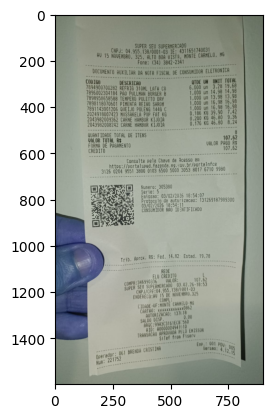

In [93]:
img_east = cv2.imread(imagem)
plt.imshow(img_east)

In [94]:
original = img_east.copy()

In [95]:
img_east.shape

(1599, 899, 3)

In [96]:
H, W = img_east.shape[:2]
print(H, W)

1599 899


In [97]:
proporcao_W = W / float(largura)
proporcao_H = H / float(altura)
print(proporcao_W)
print(proporcao_H)

2.809375
4.996875


In [98]:
img_east = cv2.resize(img_east, (largura, altura))
H = img_east.shape[0]
W = img_east.shape[1]
print(H, W)

320 320


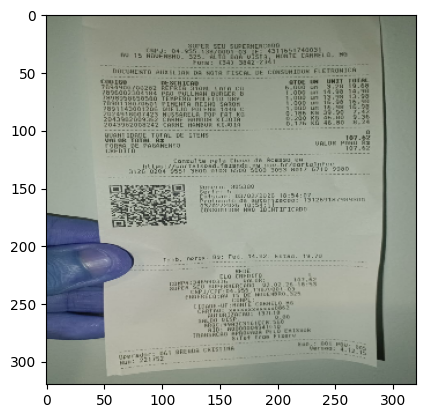

In [99]:
plt.imshow(img_east)

In [100]:
nomes_camadas = ["feature_fusion/Conv_7/Sigmoid","feature_fusion/concat_3"]

In [101]:
rede_neural = cv2.dnn.readNet(detector)

In [102]:
img_east.shape

(320, 320, 3)

In [103]:
blob = cv2.dnn.blobFromImage(img_east, 1.0, (W, H), swapRB=True, crop=False)

In [104]:
blob.shape

(1, 3, 320, 320)

In [105]:
rede_neural.setInput(blob)
scores, geometria = rede_neural.forward(nomes_camadas)

In [106]:
scores

array([[[[2.38911980e-07, 1.76342644e-06, 8.69287419e-07, ...,
          2.41246397e-07, 1.93211420e-08, 1.00477678e-06],
         [2.24001337e-06, 1.30770763e-06, 1.09139160e-06, ...,
          2.24369910e-06, 3.18715621e-07, 1.32694504e-06],
         [1.59972637e-06, 1.17664013e-06, 1.10965425e-06, ...,
          2.48150718e-06, 5.41388268e-08, 1.84150508e-06],
         ...,
         [1.48513152e-06, 9.07412073e-07, 1.16927743e-06, ...,
          2.73367732e-07, 1.61884595e-09, 2.68347757e-12],
         [1.36776430e-06, 5.92264712e-07, 4.86739282e-07, ...,
          8.19394188e-08, 4.68243444e-10, 8.66041058e-11],
         [8.82592758e-07, 1.16700654e-07, 2.61461910e-08, ...,
          3.96608790e-09, 9.44813894e-10, 1.63663777e-10]]]],
      dtype=float32)

In [107]:
geometria

array([[[[ 1.61229080e+02,  1.28750595e+02,  1.31744278e+02, ...,
           1.46452103e+02,  1.35939072e+02,  1.62678680e+02],
         [ 1.32162262e+02,  7.29292526e+01,  7.56285324e+01, ...,
           9.46366425e+01,  9.12794342e+01,  1.18002441e+02],
         [ 1.37593445e+02,  7.83071747e+01,  8.12331314e+01, ...,
           1.05988976e+02,  1.00282600e+02,  1.20038261e+02],
         ...,
         [ 1.49030197e+02,  8.90455551e+01,  9.69918442e+01, ...,
           1.69919395e+01,  1.74907742e+01,  3.19871063e+01],
         [ 1.48901367e+02,  9.13801956e+01,  1.01999054e+02, ...,
           2.21188564e+01,  2.28739014e+01,  3.89348602e+01],
         [ 1.85017685e+02,  1.45200027e+02,  1.58647156e+02, ...,
           3.29409180e+01,  3.44760323e+01,  6.72178726e+01]],

        [[ 1.15304085e+02,  8.86248627e+01,  8.61468430e+01, ...,
           9.92341003e+01,  9.51793442e+01,  1.16143524e+02],
         [ 8.63692398e+01,  4.93425560e+01,  4.76344070e+01, ...,
           5.95497780e

In [108]:
print(scores.shape)
print(geometria.shape)

(1, 1, 80, 80)
(1, 5, 80, 80)


In [109]:
linhas, colunas = scores.shape[2:4]
print(linhas)
print(colunas)

80
80


In [110]:
caixas = []
confiancas = []

In [111]:
def dados_geometricos(geometria, y):
    xData0 = geometria[0, 0, y]
    xData1 = geometria[0, 1, y]
    xData2 = geometria[0, 2, y]
    xData3 = geometria[0, 3, y]
    angulo = geometria[0, 4, y]
    return angulo, xData0, xData1, xData2, xData3

In [112]:
def calculos_geometria(angulo, xData0, xData1, xData2, xData3):
    import math
    (offsetX, offsetY) = (x * 4.0, y * 4.0)
    angulo_X = angulo[x]
    cos = np.cos(angulo_X)
    sin = np.sin(angulo_X)
    
    h = xData0[x] + xData2[x]
    w = xData1[x] + xData3[x]
    
    fimX = int(offsetX + (cos * xData1[x]) + (sin * xData2[x]))
    fimY = int(offsetY - (sin * xData1[x]) + (cos * xData2[x]))
    inicioX = int(fimX - w)
    inicioY = int(fimY - h)

    return inicioX, inicioY, fimX, fimY

In [113]:
for y in range(0, linhas):
    scoresData = scores[0, 0, y]
    angulo, xData0, xData1, xData2, xData3 = dados_geometricos(geometria, y)
    
    for x in range(0, colunas):
        if scoresData[x] < min_confianca:
            continue
        
        inicioX, inicioY, fimX, fimY = calculos_geometria(angulo, xData0, xData1, xData2, xData3)
        
        inicioX = int(inicioX * proporcao_W)
        inicioY = int(inicioY * proporcao_H)
        fimX = int(fimX * proporcao_W)
        fimY = int(fimY * proporcao_H)
        
        caixas.append((inicioX, inicioY, fimX, fimY))
        confiancas.append(float(scoresData[x]))

In [114]:
caixas

[(230, 129, 337, 199),
 (235, 129, 337, 199),
 (233, 129, 331, 199),
 (238, 129, 331, 194),
 (247, 129, 331, 194),
 (252, 134, 334, 194),
 (528, 134, 618, 199),
 (536, 129, 615, 194),
 (539, 124, 615, 189),
 (542, 124, 618, 189),
 (547, 129, 632, 189),
 (587, 129, 685, 189),
 (601, 129, 693, 189),
 (606, 124, 696, 184),
 (612, 124, 696, 184),
 (615, 134, 699, 189),
 (618, 134, 705, 189),
 (216, 634, 306, 694),
 (219, 634, 300, 694),
 (219, 634, 300, 694),
 (148, 869, 250, 934),
 (320, 1024, 398, 1079),
 (323, 1024, 396, 1084),
 (325, 1024, 398, 1089),
 (292, 1134, 379, 1204),
 (292, 1129, 376, 1199),
 (575, 1099, 679, 1189),
 (292, 1129, 379, 1204),
 (292, 1134, 373, 1204),
 (553, 1319, 663, 1394),
 (559, 1319, 663, 1394),
 (561, 1319, 663, 1394),
 (561, 1324, 660, 1394),
 (553, 1324, 660, 1399),
 (598, 1394, 685, 1459),
 (370, 1409, 455, 1474),
 (373, 1409, 460, 1474),
 (376, 1409, 463, 1474),
 (601, 1394, 691, 1464),
 (606, 1399, 696, 1464),
 (606, 1399, 696, 1469),
 (612, 1399, 702,

In [115]:
confiancas

[0.9958131909370422,
 0.9990135431289673,
 0.9988753199577332,
 0.9984055161476135,
 0.9969515800476074,
 0.980263888835907,
 0.9995090961456299,
 0.9999227523803711,
 0.9999595880508423,
 0.9999393224716187,
 0.9981766939163208,
 0.9996551275253296,
 0.9999538660049438,
 0.9999645948410034,
 0.9999573230743408,
 0.999839186668396,
 0.9983691573143005,
 0.9949040412902832,
 0.9992805123329163,
 0.9992497563362122,
 0.9468339681625366,
 0.9937835931777954,
 0.9988008737564087,
 0.9983336329460144,
 0.992037296295166,
 0.9995600581169128,
 0.943981945514679,
 0.99558025598526,
 0.9987553358078003,
 0.9985291957855225,
 0.9995119571685791,
 0.9997115731239319,
 0.9994274377822876,
 0.9993138313293457,
 0.9949110150337219,
 0.9998509883880615,
 0.9998774528503418,
 0.9997001886367798,
 0.954529345035553,
 0.9998133778572083,
 0.9999090433120728,
 0.9998875856399536,
 0.9997569918632507,
 0.999313473701477,
 0.9999288320541382,
 0.9999254941940308,
 0.9998372793197632,
 0.9992326498031616,


In [116]:
from imutils.object_detection import non_max_suppression
import numpy as np

# Agora a chamada da função será reconhecida
detecoes = non_max_suppression(np.array(caixas), probs=confiancas)

In [117]:
detecoes

array([[ 606,  124,  696,  184],
       [ 539,  124,  615,  189],
       [ 702, 1414,  783, 1484],
       [ 606, 1399,  696, 1469],
       [ 373, 1409,  460, 1474],
       [ 561, 1319,  663, 1394],
       [ 306, 1419,  387, 1484],
       [ 292, 1129,  376, 1199],
       [ 202, 1439,  309, 1504],
       [ 219,  634,  300,  694],
       [ 235,  129,  337,  199],
       [ 323, 1024,  396, 1084],
       [ 148,  869,  250,  934],
       [ 575, 1099,  679, 1189]])

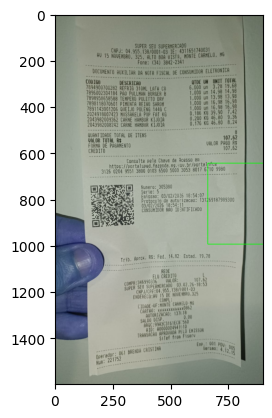

In [118]:
copia = original.copy()
for (inicioX, inicioY, fimX, fimY) in detecoes:
    inicioX = int(inicioX * proporcao_W)
    inicioY = int(inicioY * proporcao_H)
    fimX = int(fimX * proporcao_W)
    fimY = int(fimY * proporcao_H)
    
    roi = copia[inicioY:fimY, inicioX:fimX]
    cv2.rectangle(original, (inicioX, inicioY), (fimX, fimY), (0, 255, 0), 2)
plt.imshow(original) 

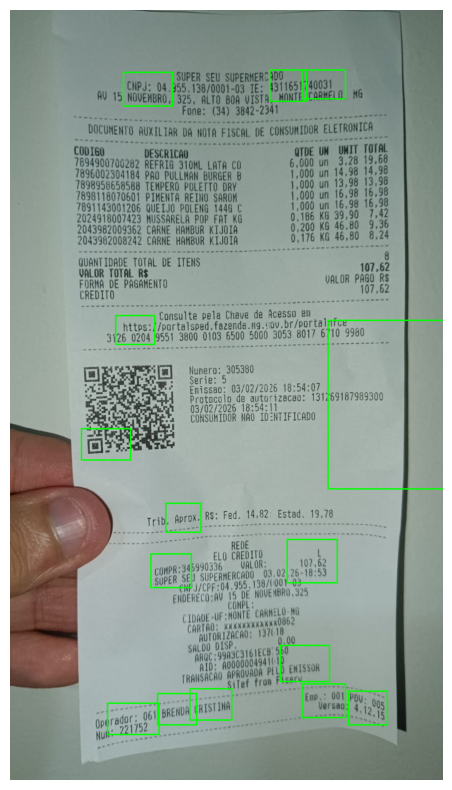

In [120]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from imutils.object_detection import non_max_suppression

def processar_deteccao_texto(scores, geometria, min_confianca=0.5):
    # Dimensões da saída do modelo
    (num_linhas, num_colunas) = scores.shape[2:4]
    caixas = []
    confiancas = []

    # Vetorização: Encontrar apenas os índices que superam a confiança mínima
    indices = np.where(scores[0, 0, :, :] >= min_confianca)

    for y, x in zip(*indices):
        # 1. Offset baseado na redução do modelo (o EAST reduz a imagem em 4x)
        offset_x, offset_y = x * 4.0, y * 4.0
        
        # 2. Extração dos dados geométricos (distâncias e ângulo)
        # d0=topo, d1=direita, d2=baixo, d3=esquerda
        d0, d1, d2, d3, angulo = [geometria[0, i, y, x] for i in range(5)]
        
        # 3. Cálculo da rotação usando trigonometria
        cos, sin = np.cos(angulo), np.sin(angulo)
        h = d0 + d2
        w = d1 + d3

        # Coordenadas finais baseadas na rotação do texto
        fim_x = int(offset_x + (cos * d1) + (sin * d2))
        fim_y = int(offset_y - (sin * d1) + (cos * d2))
        inicio_x = int(fim_x - w)
        inicio_y = int(fim_y - h)

        caixas.append((inicio_x, inicio_y, fim_x, fim_y))
        confiancas.append(float(scores[0, 0, y, x]))

    return np.array(caixas), confiancas

# --- Execução Principal ---

# Obtendo as caixas na escala do modelo (geralmente 320x320)
caixas_brutas, confs = processar_deteccao_texto(scores, geometria, min_confianca)

# Aplicando NMS para eliminar sobreposições
# 
detecoes = non_max_suppression(caixas_brutas, probs=confs)

# Criando cópia para visualização
resultado_img = original.copy()

for (iX, iY, fX, fY) in detecoes:
    # ESCALA ÚNICA: Ajustando para o tamanho original da imagem
    iX = int(iX * proporcao_W)
    iY = int(iY * proporcao_H)
    fX = int(fX * proporcao_W)
    fY = int(fY * proporcao_H)

    # Garantir que o ROI está dentro da imagem
    iX, iY = max(0, iX), max(0, iY)
    fX, fY = min(original.shape[1], fX), min(original.shape[0], fY)

    # Extração do ROI para futuro OCR
    roi = resultado_img[iY:fY, iX:fX]
    
    # Desenhar retângulo no canvas original
    cv2.rectangle(original, (iX, iY), (fX, fY), (0, 255, 0), 2)

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()